<a href="https://colab.research.google.com/github/gulzhanmsc/IB9AU/blob/main/Gen_AI_Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gulzhan Aitileu

Key insights: PyTorch taught me that data has to be converted into tensors before the model can do anything with it. Writing the training loop manually was the most valuable part, watching the loss drop over each epoch and seeing how the optimizer updates weights made the whole learning process click. Small details like model.eval() and torch.no_grad() during testing turned out to matter more than I expected. The most rewarding moment was visualizing the results: the model's mistakes weren't random, it was mostly confusing similar-looking classes like "Shirt" and "T-shirt," which made the whole thing feel a lot more understandable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import torch
from torchvision import datasets, transforms

# Load the FashionMNIST dataset
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 302kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.6MB/s]


In [3]:
train_dataset.transform = transforms.ToTensor()
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

In [4]:
from torch.utils.data import DataLoader

# Create training DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Create testing DataLoader
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [5]:
import torch.nn as nn

class ImageMLP(nn.Module):
    def __init__(self):
        super(ImageMLP, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.main(x)

model = ImageMLP()

In [6]:
import torch.optim as optim

# Define the loss function and the optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop for 10 epochs
for epoch in range(10):
    for images, labels in train_loader:
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

In [7]:
# Set the model to evaluation mode
model.eval()

correct = 0
total = 0

# Disable gradient calculation for efficiency
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate and print the final accuracy
accuracy = 100 * correct / total
print(f'Accuracy on the 10,000 test images: {accuracy:.2f}%')

Accuracy on the 10,000 test images: 88.33%


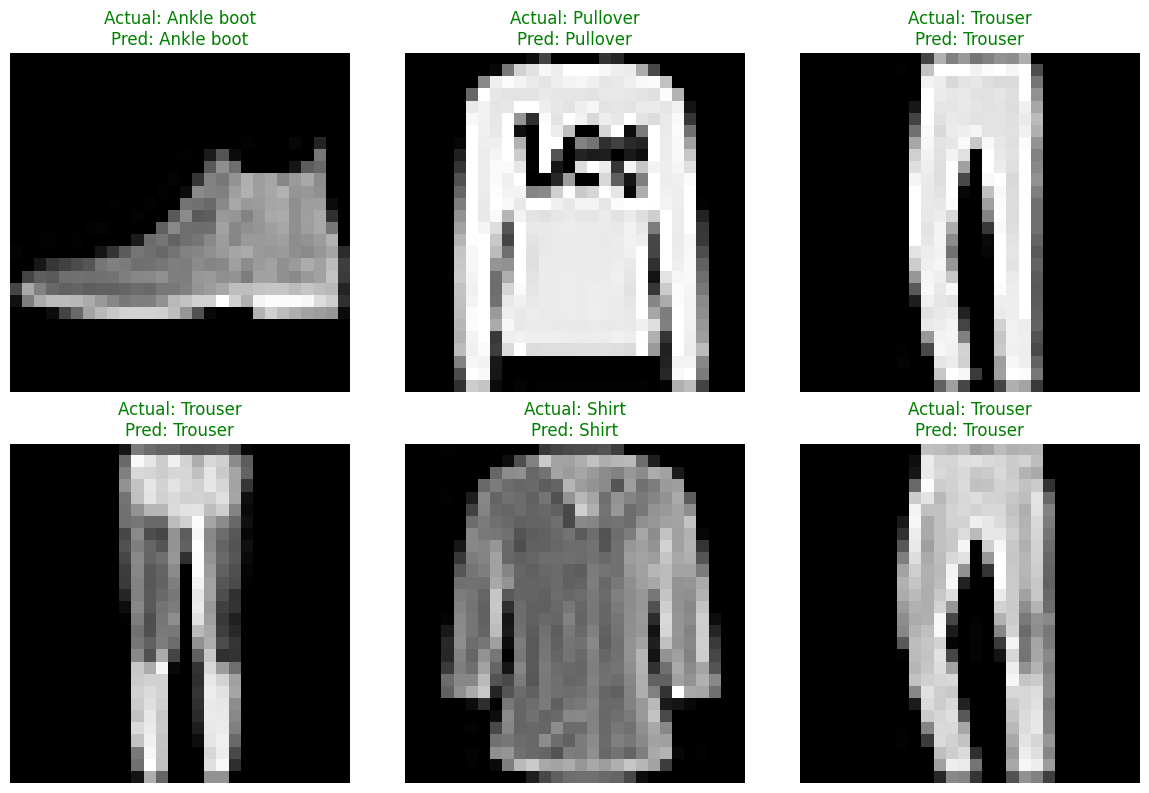

In [8]:
# Get one batch of test images
images, labels = next(iter(test_loader))
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Class names for FashionMNIST
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plot the first 6 images from the batch
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i+1)
    img = images[i].squeeze()
    plt.imshow(img, cmap='gray')

    color = 'green' if predicted[i] == labels[i] else 'red'
    plt.title(f"Actual: {classes[labels[i]]}\nPred: {classes[predicted[i]]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()